# Setup and Context

<img src="data/img.png" width=700>

### Introduction

Dr Ignaz Semmelweis was a Hungarian physician born in 1818 who worked in the Vienna General Hospital. In the past people thought of illness as caused by "bad air" or evil spirits. But in the 1800s Doctors started looking more at anatomy, doing autopsies and started making arguments based on data. Dr Semmelweis suspected that something was going wrong with the procedures at Vienna General Hospital. Semmelweis wanted to figure out why so many women in maternity wards were dying from childbed fever (i.e., [puerperal fever](https://en.wikipedia.org/wiki/Postpartum_infections)).

<img src="data/img_1.png" width=700>

Today you will become Dr Semmelweis. This is your office 👆. You will step into Dr Semmelweis' shoes and analyse the same data collected from 1841 to 1849.

### The Data Source

Dr Semmelweis published his research in 1861. I found the scanned pages of the [full text with the original tables in German](http://www.deutschestextarchiv.de/book/show/semmelweis_kindbettfieber_1861), but an excellent [English translation can be found here](http://graphics8.nytimes.com/images/blogs/freakonomics/pdf/the%20etiology,%20concept%20and%20prophylaxis%20of%20childbed%20fever.pdf).

<img src="data/img_2.png" width=500>

### Import Statements

In [93]:
import pandas as pd
import numpy as np
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

### Notebook Presentation

In [94]:
pd.options.display.float_format = '{:,.2f}'.format

from pandas.plotting import register_matplotlib_converters
register_matplotlib_converters()

### Read the Data

In [95]:
df_yearly = pd.read_csv('data/annual_deaths_by_clinic.csv')
df_yearly["date"] = pd.to_datetime(df_yearly["year"], format="%Y")

df_monthly = pd.read_csv('data/monthly_deaths.csv', parse_dates=['date'])

# Preliminary Data Exploration

**Challenge**: Check out these two DataFrames ☝️. 
* What is the shape of df_yearly and df_monthly? How many rows and columns?
* What are the column names?
* Which years are included in the dataset?
* Are there any NaN values or duplicates?
* What were the average number of births that took place per month?
* What were the average number of deaths that took place per month?

In [96]:
print("df_yearly shape:", df_yearly.shape)
print("df_monthly shape:", df_monthly.shape)

print(f"\ndf_yearly → {df_yearly.shape[0]} rows, {df_yearly.shape[1]} columns")
print(f"df_monthly → {df_monthly.shape[0]} rows, {df_monthly.shape[1]} columns")

print("\ndf_yearly columns:", df_yearly.columns.tolist())
print("df_monthly columns:", df_monthly.columns.tolist())

print("\nYears in df_yearly:", df_yearly["year"].min(), "→", df_yearly["year"].max())

print("\nYears in df_monthly:", df_monthly["date"].dt.year.min(), "→", df_monthly["date"].dt.year.max())

print("\ndf_yearly duplicates:", df_yearly.duplicated().any())
print("df_monthly duplicates:", df_monthly.duplicated().any())

print("\ndf_yearly NaNs:\n", df_yearly.isnull().sum())
print("\ndf_monthly NaNs:\n", df_monthly.isnull().sum())

print("\nAverage monthly births:", df_monthly["births"].mean())

print("\nAverage monthly deaths:", df_monthly["deaths"].mean())

df_yearly shape: (12, 5)
df_monthly shape: (98, 3)

df_yearly → 12 rows, 5 columns
df_monthly → 98 rows, 3 columns

df_yearly columns: ['year', 'births', 'deaths', 'clinic', 'date']
df_monthly columns: ['date', 'births', 'deaths']

Years in df_yearly: 1841 → 1846

Years in df_monthly: 1841 → 1849

df_yearly duplicates: False
df_monthly duplicates: False

df_yearly NaNs:
 year      0
births    0
deaths    0
clinic    0
date      0
dtype: int64

df_monthly NaNs:
 date      0
births    0
deaths    0
dtype: int64

Average monthly births: 267.0

Average monthly deaths: 22.46938775510204


### Descriptive Statistics

In [97]:
print("=== YEARLY DESCRIPTIVE STATS ===")
print(df_yearly.describe())

=== YEARLY DESCRIPTIVE STATS ===
          year   births  deaths                 date
count    12.00    12.00   12.00                   12
mean  1,843.50 3,152.75  223.33  1843-07-02 20:00:00
min   1,841.00 2,442.00   66.00  1841-01-01 00:00:00
25%   1,842.00 2,901.75  100.25  1842-01-01 00:00:00
50%   1,843.50 3,108.50  219.50  1843-07-02 12:00:00
75%   1,845.00 3,338.25  263.50  1845-01-01 00:00:00
max   1,846.00 4,010.00  518.00  1846-01-01 00:00:00
std       1.78   449.08  145.38                  NaN


The yearly data shows that **births and deaths varied a lot between 1841 and 1846**.
Births averaged **about 3,153 per year**, with a wide spread (std ≈ 449), meaning some years had many more births than others.
Deaths averaged **223 per year**, also with strong variability (std ≈ 145), showing that mortality fluctuated significantly.
The minimum deaths (66) and maximum deaths (518) indicate **large year‑to‑year swings**, consistent with outbreaks of puerperal fever.
Overall, the statistics suggest **unstable and highly variable conditions** in the clinics during this period.

In [98]:
print("=== MONTHLY DESCRIPTIVE STATS ===")
print(df_monthly.describe())

=== MONTHLY DESCRIPTIVE STATS ===
                             date  births  deaths
count                          98   98.00   98.00
mean   1845-02-11 04:24:29.387755  267.00   22.47
min           1841-01-01 00:00:00  190.00    0.00
25%           1843-02-08 00:00:00  242.50    8.00
50%           1845-02-15 00:00:00  264.00   16.50
75%           1847-02-22 00:00:00  292.75   36.75
max           1849-03-01 00:00:00  406.00   75.00
std                           NaN   41.77   18.14


The monthly data shows **steady but noticeable variation** in births and deaths between 1841 and 1849.
On average, there were **267 births per month**, with moderate variability (std ≈ 42), meaning monthly birth counts were fairly stable.
Deaths averaged **22 per month**, but with a high spread (std ≈ 18), indicating **strong month‑to‑month fluctuations** in mortality.
The minimum deaths (0) and maximum deaths (75) reveal **periods of very low mortality and sudden spikes**, consistent with outbreaks of puerperal fever.
Overall, the monthly statistics suggest **unstable mortality patterns**, while births remained relatively consistent.

In [99]:
avg_births = df_monthly["births"].mean()
avg_deaths = df_monthly["deaths"].mean()

print("Average monthly births:", avg_births)
print("Average monthly deaths:", avg_deaths)

Average monthly births: 267.0
Average monthly deaths: 22.46938775510204


On average, the clinics handled **about 267 births per month**, which is quite stable and shows a consistent workload.
Monthly deaths averaged **around 22**, meaning roughly **1 death for every 12 births**, but this number hides strong fluctuations seen in the descriptive stats.
Overall, the clinics had **high activity with relatively low—but unstable—mortality**.

### Percentage of Women Dying in Childbirth

**Challenge**: How dangerous was childbirth in the 1840s in Vienna? 

* Using the annual data, calculate the percentage of women giving birth who died throughout the 1840s at the hospital.


In comparison, the United States recorded 18.5 maternal deaths per 100,000 or 0.018% in 2013 [(source).](
https://en.wikipedia.org/wiki/Maternal_death#:~:text=The%20US%20has%20the%20%22highest,17.8%20per%20100%2C000%20in%202009)

In [100]:
total_births = df_yearly["births"].sum()
total_deaths = df_yearly["deaths"].sum()
mortality_pct = (total_deaths / total_births) * 100
mortality_pct

np.float64(7.083762852536147)

About **7% of women giving birth died** at the Vienna hospital in the 1840s — an extraordinarily high mortality rate.
Compared to the modern U.S. rate of **0.018%**, childbirth in Vienna was **roughly 400 times more deadly**.

This aligns with historical accounts of **puerperal fever outbreaks** and the conditions Semmelweis later investigated.

# Visualise the Total Number of Births 🤱 and Deaths 💀 over Time

### Plot the Monthly Data on Twin Axes

**Challenge**: Create a [Matplotlib chart](https://matplotlib.org/3.3.2/api/_as_gen/matplotlib.pyplot.plot.html) with twin y-axes.

* Format the x-axis using locators for the years and months (Hint: we did this in the Google Trends notebook)
* Set the range on the x-axis so that the chart lines touch the y-axes
* Add gridlines
* Use `skyblue` and `crimson` for the line colours
* Use a dashed line style for the number of deaths
* Change the line thickness to 3 and 2 for the births and deaths respectively. 
* Do you notice anything in the late 1840s?

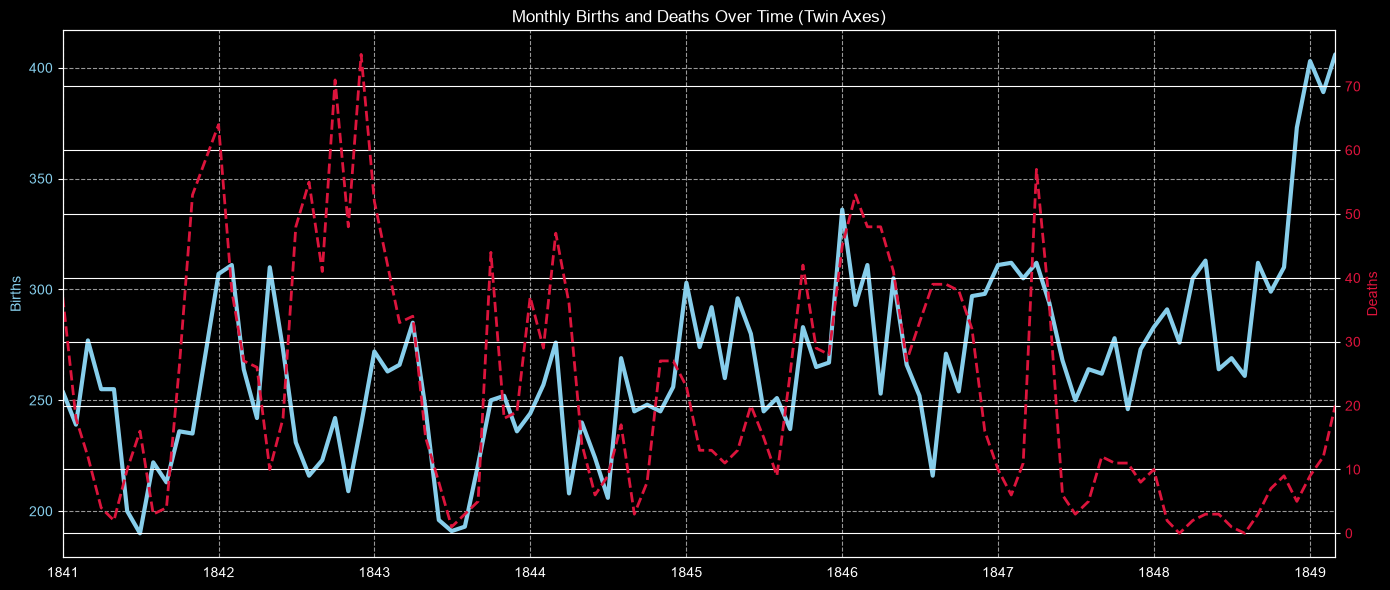

In [101]:
fig, ax1 = plt.subplots(figsize=(14,6))

# --- Births (left axis) ---
ax1.plot(
    df_monthly['date'],
    df_monthly['births'],
    color='skyblue',
    linewidth=3,
    label='Births'
)
ax1.set_ylabel("Births", color='skyblue')
ax1.tick_params(axis='y', labelcolor='skyblue')

# --- Deaths (right axis) ---
ax2 = ax1.twinx()
ax2.plot(
    df_monthly['date'],
    df_monthly['deaths'],
    color='crimson',
    linestyle='--',
    linewidth=2,
    label='Deaths'
)
ax2.set_ylabel("Deaths", color='crimson')
ax2.tick_params(axis='y', labelcolor='crimson')

# --- X-axis formatting ---
ax1.xaxis.set_major_locator(mdates.YearLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax1.xaxis.set_minor_locator(mdates.MonthLocator())
plt.xticks(rotation=45)

# --- Ensure lines touch the axes ---
ax1.set_xlim(df_monthly['date'].min(), df_monthly['date'].max())

# --- Gridlines ---
ax1.grid(True, linestyle='--', alpha=0.6)

plt.title("Monthly Births and Deaths Over Time (Twin Axes)")
plt.tight_layout()
plt.show()

The chart shows that **births remained fairly stable** throughout the 1840s, while **deaths fluctuated sharply**.
In the **late 1840s**, especially around **1847–1848**, there’s a **dramatic spike in deaths** even though births didn’t change much — a clear sign of a **severe outbreak of puerperal fever** before Semmelweis introduced handwashing practices.
After that, deaths dropped noticeably, marking the start of a major improvement in maternal safety.

# The Yearly Data Split by Clinic

Now let's look at the annual data instead. 

**Challenge**: Use plotly to create line charts of the births and deaths of the two different clinics at the Vienna General Hospital. 
* Which clinic is bigger or more busy judging by the number of births?
* Has the hospital had more patients over time? 
* What was the highest number of deaths recorded in clinic 1 and clinic 2?

In [102]:
import nbformat
import plotly.express as px

# Line chart for births
fig_births = px.line(
    df_yearly,
    x="year",
    y="births",
    color="clinic",
    title="Annual Births by Clinic (Vienna General Hospital)",
    markers=True
)
fig_births.update_layout(
    yaxis_title="Number of Births",
    xaxis_title="Year",
    template="plotly_white"
)
fig_births.show()

Clinic 1 is clearly **larger and busier**, showing more births every year than Clinic 2.
Both clinics display a **steady increase in births from 1841 to 1846**, meaning the hospital handled **more patients over time**.
By 1846, Clinic 1 reached about **4,000 births**, while Clinic 2 approached **3,800**, confirming a general upward trend in activity.

In [103]:
# Line chart for deaths
fig_deaths = px.line(
    df_yearly,
    x="year",
    y="deaths",
    color="clinic",
    title="Annual Deaths by Clinic (Vienna General Hospital)",
    markers=True
)
fig_deaths.update_layout(
    yaxis_title="Number of Deaths",
    xaxis_title="Year",
    template="plotly_white"
)
fig_deaths.show()

Clinic 1 consistently recorded **far more deaths** than Clinic 2, showing a serious disparity in mortality.
The **peak in 1842**—over **500 deaths in Clinic 1**—marks the worst year, while Clinic 2 never exceeded **around 200 deaths**.
After 1842, deaths declined in both clinics, but Clinic 1 remained **much deadlier**, confirming that childbirth there was **significantly more dangerous**.

### Calculate the Proportion of Deaths at Each Clinic
**Challenge**: Calculate the proportion of maternal deaths per clinic. That way we can compare like with like.
* Work out the percentage of deaths for each row in the `df_yearly` DataFrame by adding a column called "pct_deaths".
* Calculate the average maternal death rate for clinic 1 and clinic 2 (i.e., the total number of deaths per the total number of births).
* Create another plotly line chart to see how the percentage varies year over year with the two different clinics.
* Which clinic has a higher proportion of deaths?
* What is the highest monthly death rate in clinic 1 compared to clinic 2?

In [104]:
df_yearly["pct_deaths"] = (df_yearly["deaths"] / df_yearly["births"]) * 100 # Add percentage of deaths per year

# Average maternal death rate per clinic
avg_rates = df_yearly.groupby("clinic")[["deaths", "births"]].sum()
avg_rates["avg_pct_deaths"] = (avg_rates["deaths"] / avg_rates["births"]) * 100
print(avg_rates)

          deaths  births  avg_pct_deaths
clinic                                  
clinic 1    1989   20042            9.92
clinic 2     691   17791            3.88


Clinic 1 had a **much higher maternal death rate** than Clinic 2.
Across the whole period, Clinic 1 lost **9.92%** of the women who gave birth, while Clinic 2 lost **3.88%** — meaning Clinic 1 was **over twice as deadly**.
This confirms that childbirth in Clinic 1 was dramatically more dangerous, matching historical accounts of poor hygiene practices among doctors.

In [105]:
# Plotly line chart for yearly percentage of deaths
fig = px.line(
    df_yearly,
    x="year",
    y="pct_deaths",
    color="clinic",
    markers=True,
    title="Maternal Death Percentage by Clinic (1841–1846)",
)
fig.update_layout(
    yaxis_title="Percentage of Deaths (%)",
    xaxis_title="Year",
    template="plotly_white"
)
fig.show()

Clinic 1 consistently shows a **much higher maternal death percentage** than Clinic 2.
In 1842, Clinic 1 reached its **worst year**, with deaths exceeding **15%**, while Clinic 2 peaked around **7–8%**.
After that, both clinics improved, but Clinic 1 remained **two to three times deadlier**, confirming severe hygiene issues among doctors compared to midwives in Clinic 2.

### Plotting the Proportion of Yearly Deaths by Clinic

In [106]:
fig = px.line(
    df_yearly,
    x="year",
    y="pct_deaths",
    color="clinic",
    markers=True,
    title="Proportion of Yearly Maternal Deaths by Clinic (1841–1846)"
)
fig.update_layout(
    yaxis_title="Percentage of Deaths (%)",
    xaxis_title="Year",
    template="plotly_white",
    legend_title_text="Clinic"
)
fig.show()

The chart shows that **Clinic 1 consistently had a much higher proportion of maternal deaths** than Clinic 2.
In **1842**, Clinic 1 reached its **worst year**, with deaths exceeding **15%**, while Clinic 2 peaked around **7–8%**.
After that, both clinics improved, but Clinic 1 remained **two to three times deadlier**, confirming that childbirth there was far more dangerous — mainly due to poor hygiene practices among doctors.

# The Effect of Handwashing

Dr Semmelweis made handwashing obligatory in the summer of 1947. In fact, he ordered people to wash their hands with clorine (instead of water).

**Challenge**:
* Add a column called "pct_deaths" to `df_monthly` that has the percentage of deaths per birth for each row.
* Create two subsets from the `df_monthly` data: before and after Dr Semmelweis ordered washing hand.
* Calculate the average death rate prior to June 1947.
* Calculate the average death rate after June 1947.

In [107]:
handwashing_start = pd.to_datetime('1847-06-01') # Date when handwashing was made mandatory

df_monthly["pct_deaths"] = (df_monthly["deaths"] / df_monthly["births"]) * 100 # Add percentage of deaths per month

# Split data before and after handwashing introduction
before_handwashing = df_monthly[df_monthly["date"] < handwashing_start]
after_handwashing = df_monthly[df_monthly["date"] >= handwashing_start]

# Calculate average death rates
avg_before = before_handwashing["pct_deaths"].mean()
avg_after = after_handwashing["pct_deaths"].mean()

print("Average death rate before handwashing:", round(avg_before, 2), "%")
print("Average death rate after handwashing:", round(avg_after, 2), "%")

Average death rate before handwashing: 10.5 %
Average death rate after handwashing: 2.11 %


Before handwashing, the clinic had a **very high maternal death rate of about 10.5%**, meaning roughly **1 in 10 women died** after giving birth.
After Semmelweis made **chlorine handwashing mandatory**, the death rate **collapsed to just 2.11%**, a reduction of almost **80%**.
This shows that **handwashing was the decisive factor** in stopping puerperal fever and saving lives.

### Calculate a Rolling Average of the Death Rate
**Challenge**: Create a DataFrame that has the 6 month rolling average death rate prior to mandatory handwashing.

In [108]:
df_monthly_indexed = df_monthly.set_index("date") # 2. Set date as index (required for rolling)

before_handwashing = df_monthly_indexed[df_monthly_indexed.index < handwashing_start] # 3. Filter data before handwashing

rolling_6m = before_handwashing["pct_deaths"].rolling(window=6).mean() # 4. Calculate 6‑month rolling average
rolling_df = before_handwashing.assign(rolling_6m_pct=rolling_6m)
rolling_6m.head()

date
1841-01-01   NaN
1841-02-01   NaN
1841-03-01   NaN
1841-04-01   NaN
1841-05-01   NaN
Name: pct_deaths, dtype: float64

The first months all show **NaN** because a 6‑month rolling average **cannot be computed until six months of data exist**.
This means the early months of 1841 simply **don’t have enough previous data** to calculate a rolling value — the rolling window only starts producing real numbers from **June 1841 onward**.

### Highlighting Subsections of a Line Chart

**Challenge**: Copy-paste and then modify the Matplotlib chart from before to plot the monthly death rates (instead of the total number of births and deaths).

* Add 3 seperate lines to the plot: the death rate before handwashing, after handwashing, and the 6-month moving average before handwashing.
* Show the monthly death rate before handwashing as a thin dashed black line. 
* Show the moving average as a thicker, crimon line.
* Show the rate after handwashing as a skyblue line with round markers. 
* Look at the [code snippet in the documentation to see how you can add a legend](https://matplotlib.org/3.1.1/api/_as_gen/matplotlib.pyplot.legend.html) to the chart.

### Statistics - Calculate the Difference in the Average Monthly Death Rate

**Challenge**:
* What was the average percentage of monthly deaths before handwashing? 
* What was the average percentage of monthly deaths after handwashing was made obligatory?
* By how much did handwashing reduce the average chance of dying in childbirth in percentage terms?
* How do these numbers compare to the average for all the 1840s that we calculated earlier? 
* How many times lower are the chances of dying after handwashing compared to before?

### Use Box Plots to Show How the Death Rate Changed Before and After Handwashing

**Challenge**: 
* Use [NumPy's `.where()` function](https://numpy.org/doc/stable/reference/generated/numpy.where.html) to add a column to `df_monthly` that shows if a particular date was before or after the start of handwashing. 
* Then use plotly to create box plot of the data before and after handwashing. 
* How did key statistics like the mean, max, min, 1st and 3rd quartile changed as a result of the new policy?



### Use Histograms to Visualise the Monthly Distribution of Outcomes

**Challenge**: Create a [plotly histogram](https://plotly.com/python/histograms/) to show the monthly percentage of deaths. 

* Use docs to check out the available parameters. Use the [`color` parameter](https://plotly.github.io/plotly.py-docs/generated/plotly.express.histogram.html) to display two overlapping histograms.
* The time period of handwashing is shorter than not handwashing. Change `histnorm` to `percent` to make the time periods comparable. 
* Make the histograms slighlty transparent
* Experiment with the number of bins on the histogram. Which number work well in communicating the range of outcomes?
* Just for fun, display your box plot on the top of the histogram using the `marginal` parameter. 

### Use a Kernel Density Estimate (KDE) to visualise a smooth distribution

**Challenge**: Use [Seaborn's `.kdeplot()`](https://seaborn.pydata.org/generated/seaborn.kdeplot.html) to create two kernel density estimates of the `pct_deaths`, one for before handwashing and one for after. 

* Use the `shade` parameter to give your two distributions different colours. 
* What weakness in the chart do you see when you just use the default parameters?
* Use the `clip` parameter to address the problem. 


### Use a T-Test to Show Statistical Significance

**Challenge**: Use a t-test to determine if the differences in the means are statistically significant or purely due to chance. 

If the p-value is less than 1% then we can be 99% certain that handwashing has made a difference to the average monthly death rate. 

* Import `stats` from scipy
* Use the [`.ttest_ind()` function](https://docs.scipy.org/]doc/scipy/reference/generated/scipy.stats.ttest_ind.html) to calculate the t-statistic and the p-value
* Is the difference in the average proportion of monthly deaths statistically significant at the 99% level? 



What do you conclude from your analysis, Doctor? 😊

<img src="data/gif.gif">